<a href="https://colab.research.google.com/github/ibrahimbugrasan/HasarliAracTespiti-2/blob/main/BeitModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/276 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/models/beit/feature_extraction_beit.py:28: FutureWarning: The class BeitFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use BeitImageProcessor instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/utils/deprecation.py:165: UserWarning: The following named arguments are not valid for `BeitFeatureExtractor.__init__` and were ignored: 'feature_extractor_type'
  return func(*args, **kwargs)


config.json:   0%|          | 0.00/69.9k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/350M [00:00<?, ?B/s]

Some weights of BeitForImageClassification were not initialized from the model checkpoint at microsoft/beit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([4]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([4, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch [1/10]
Accuracy: 0.9959, Recall: 0.9956, Precision: 0.9950, F1-Score: 0.9953, AUC: 0.9972
Training Loss: 0.2000, Validation Loss: 0.0290


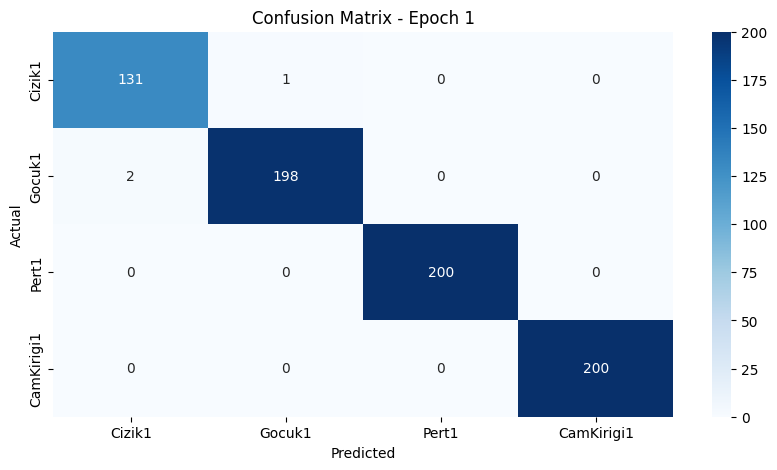

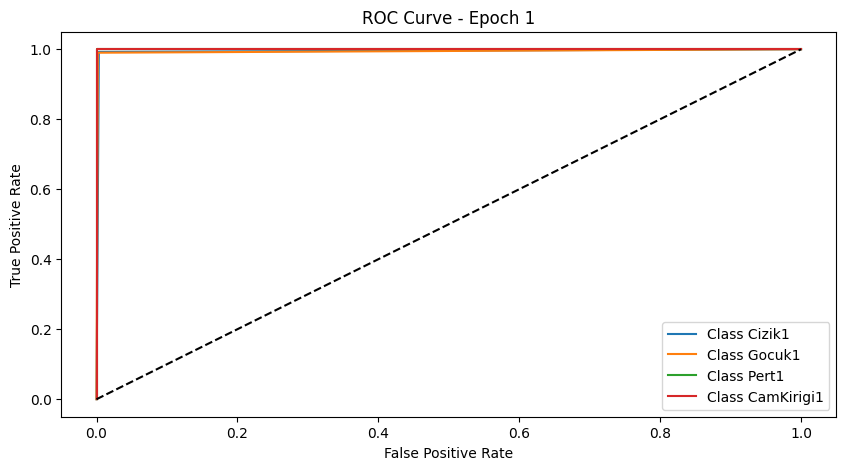

Epoch [2/10]
Accuracy: 0.9850, Recall: 0.9798, Precision: 0.9860, F1-Score: 0.9825, AUC: 0.9873
Training Loss: 0.0197, Validation Loss: 0.0353


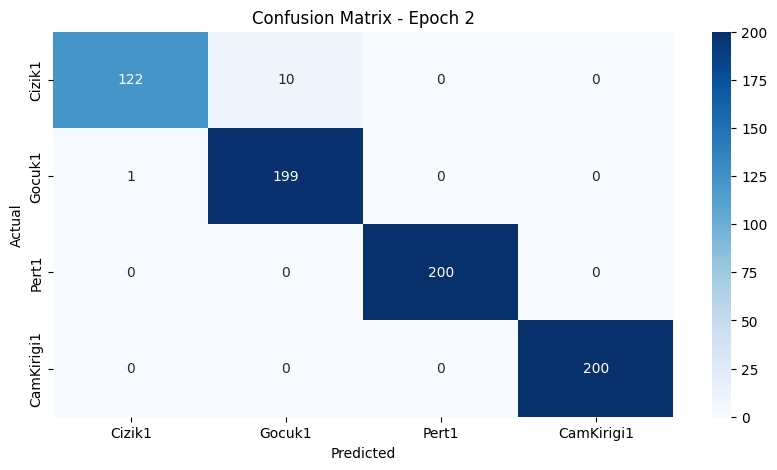

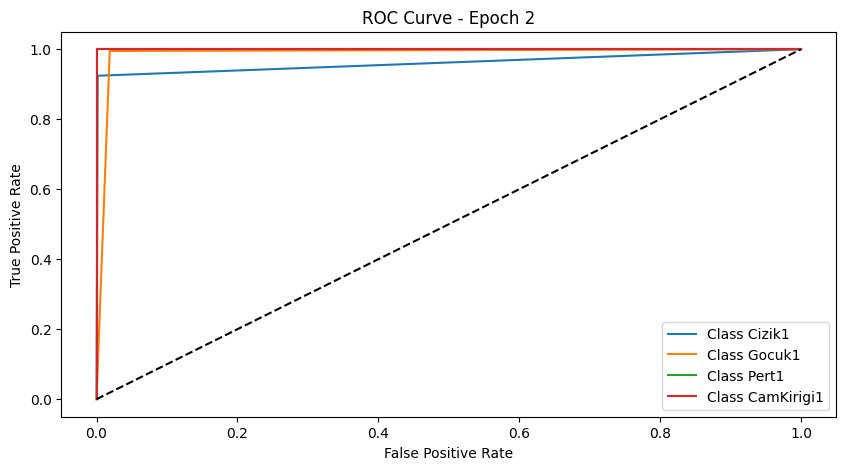

Epoch [3/10]
Accuracy: 0.9836, Recall: 0.9792, Precision: 0.9840, F1-Score: 0.9813, AUC: 0.9868
Training Loss: 0.0196, Validation Loss: 0.0404


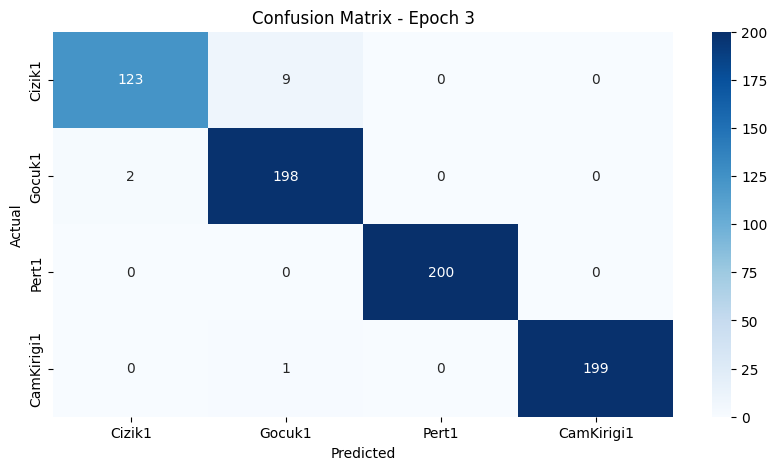

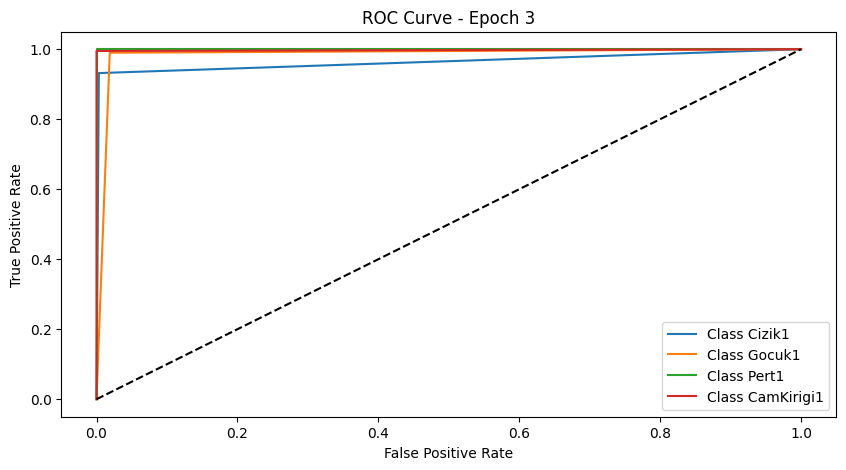

Epoch [4/10]
Accuracy: 0.9904, Recall: 0.9912, Precision: 0.9890, F1-Score: 0.9900, AUC: 0.9941
Training Loss: 0.0186, Validation Loss: 0.0279


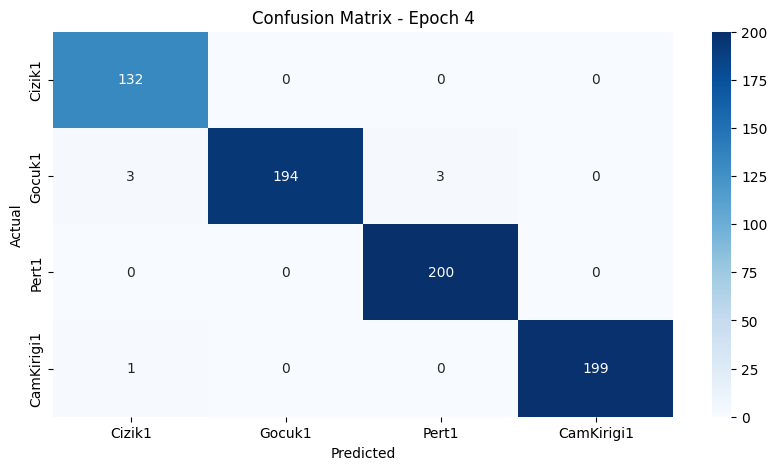

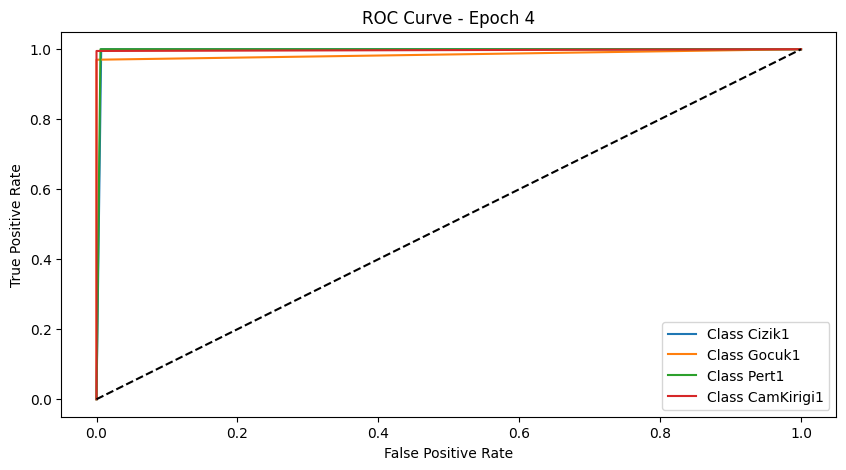

Epoch [5/10]
Accuracy: 0.9822, Recall: 0.9818, Precision: 0.9796, F1-Score: 0.9807, AUC: 0.9880
Training Loss: 0.0203, Validation Loss: 0.0609


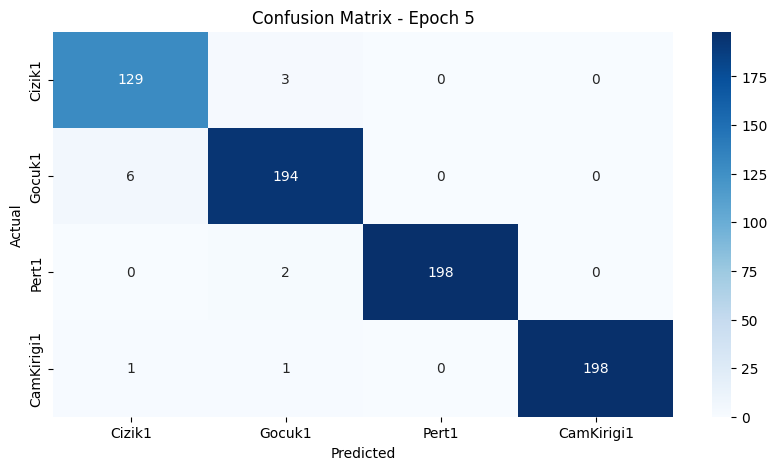

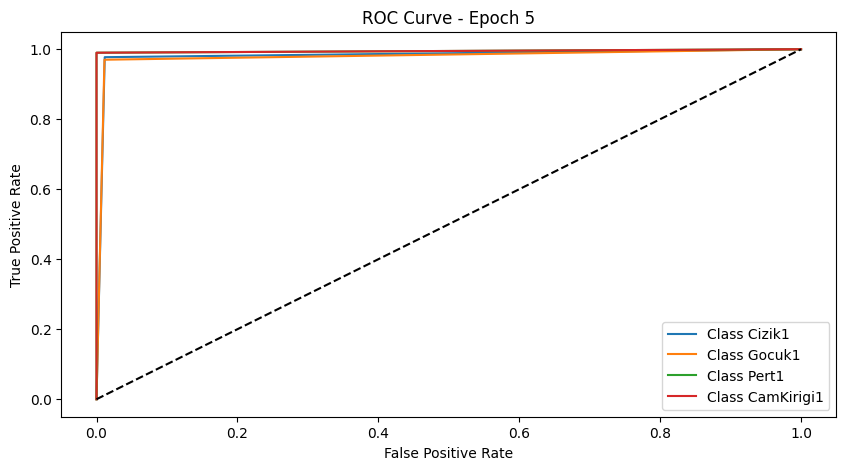

Epoch [6/10]
Accuracy: 0.9781, Recall: 0.9710, Precision: 0.9811, F1-Score: 0.9750, AUC: 0.9817
Training Loss: 0.0232, Validation Loss: 0.0613


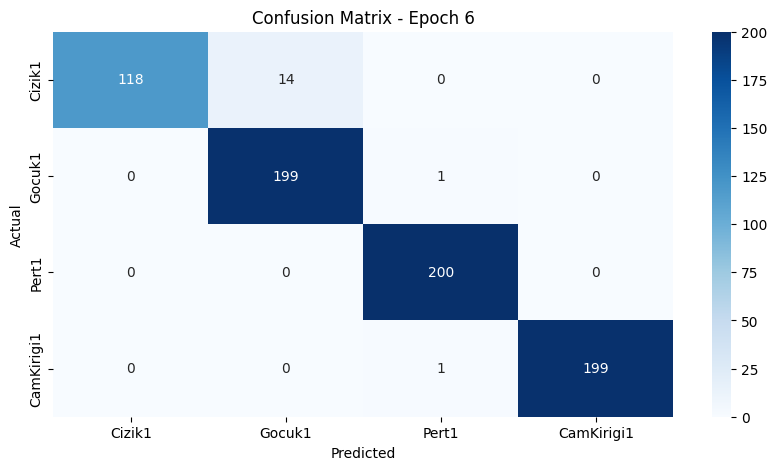

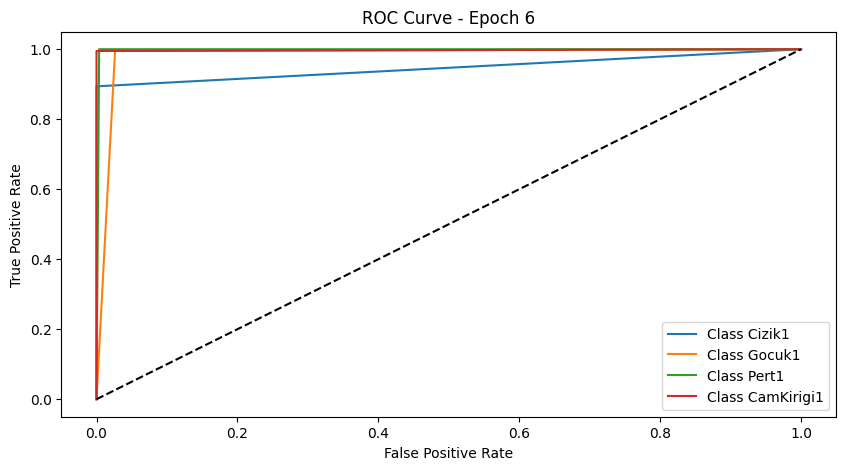

Epoch [7/10]
Accuracy: 0.9986, Recall: 0.9988, Precision: 0.9981, F1-Score: 0.9984, AUC: 0.9992
Training Loss: 0.0084, Validation Loss: 0.0049


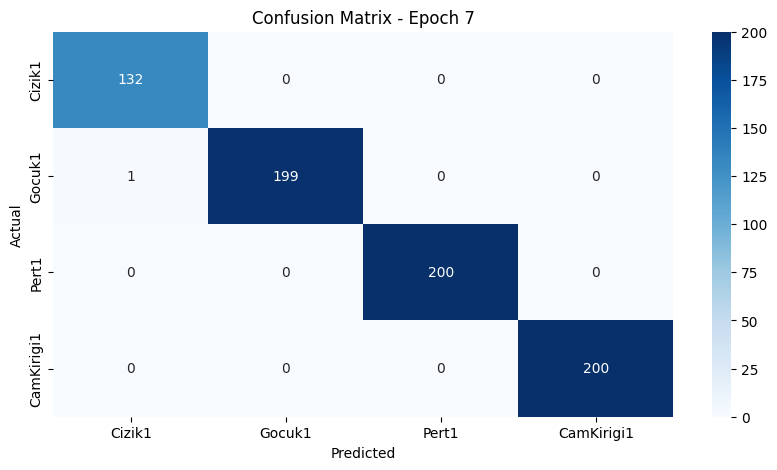

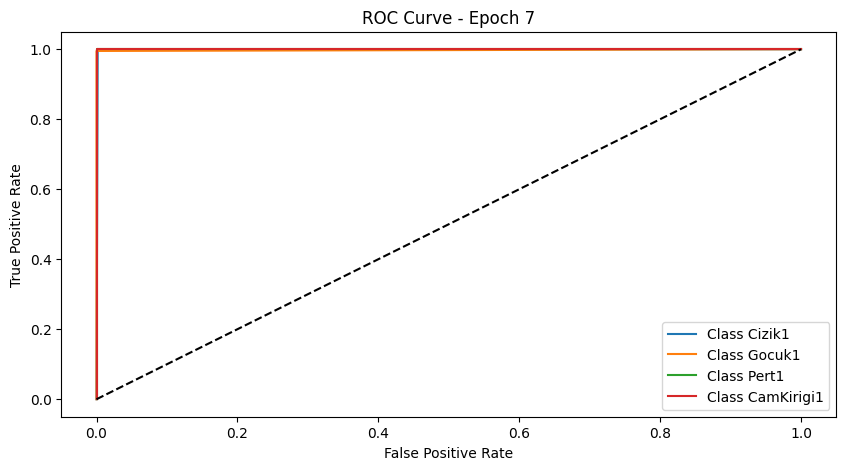

Epoch [8/10]
Accuracy: 0.9945, Recall: 0.9950, Precision: 0.9926, F1-Score: 0.9937, AUC: 0.9967
Training Loss: 0.0017, Validation Loss: 0.0137


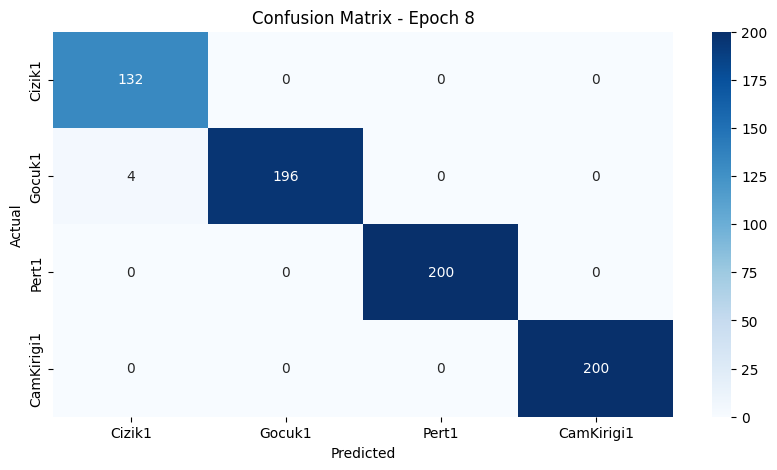

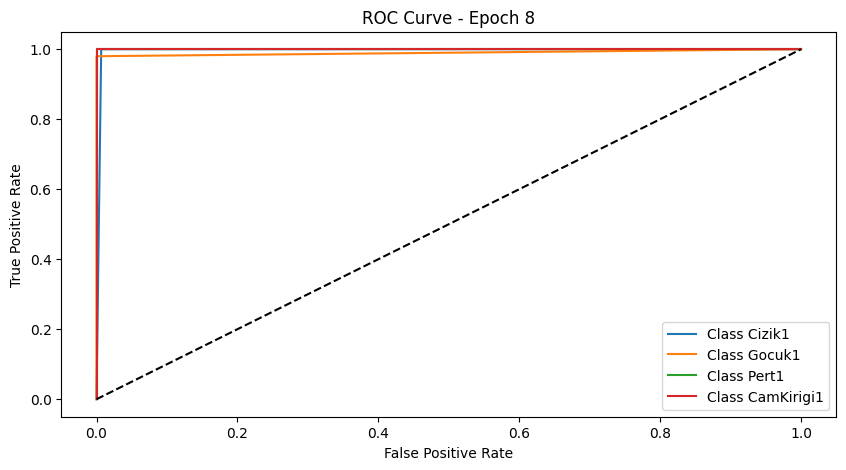

Epoch [9/10]
Accuracy: 0.9973, Recall: 0.9975, Precision: 0.9963, F1-Score: 0.9969, AUC: 0.9983
Training Loss: 0.0034, Validation Loss: 0.0098


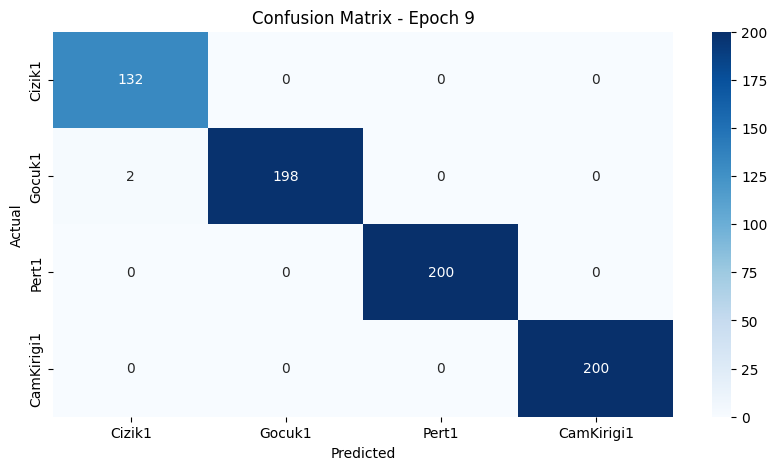

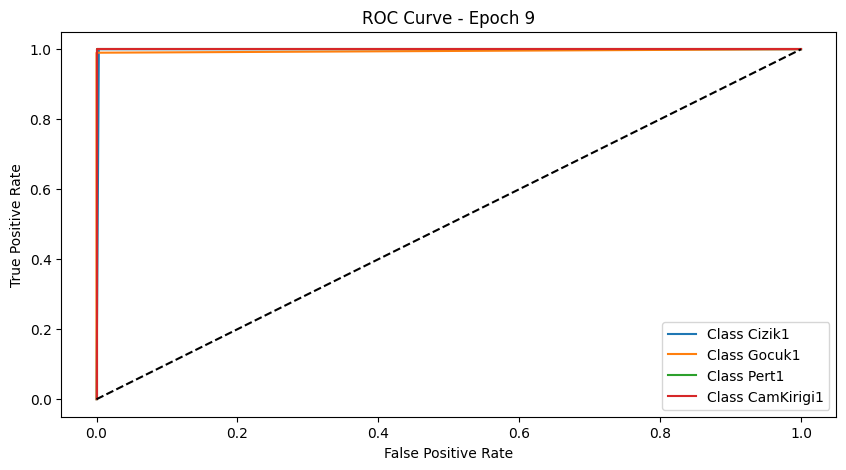

Epoch [10/10]
Accuracy: 0.9973, Recall: 0.9975, Precision: 0.9963, F1-Score: 0.9969, AUC: 0.9983
Training Loss: 0.0026, Validation Loss: 0.0072


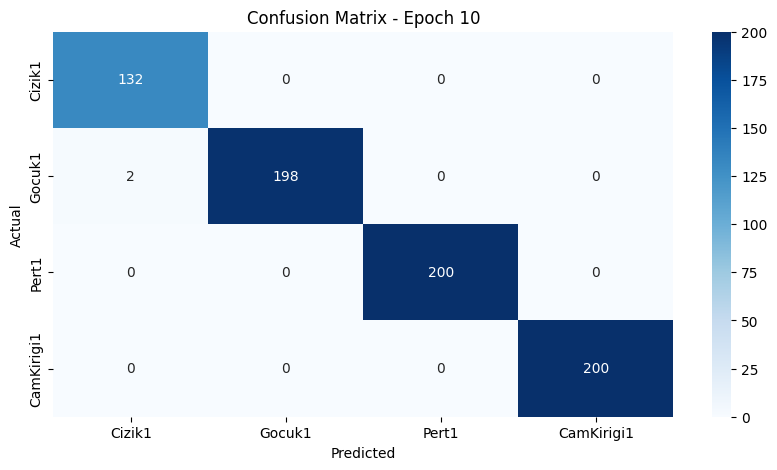

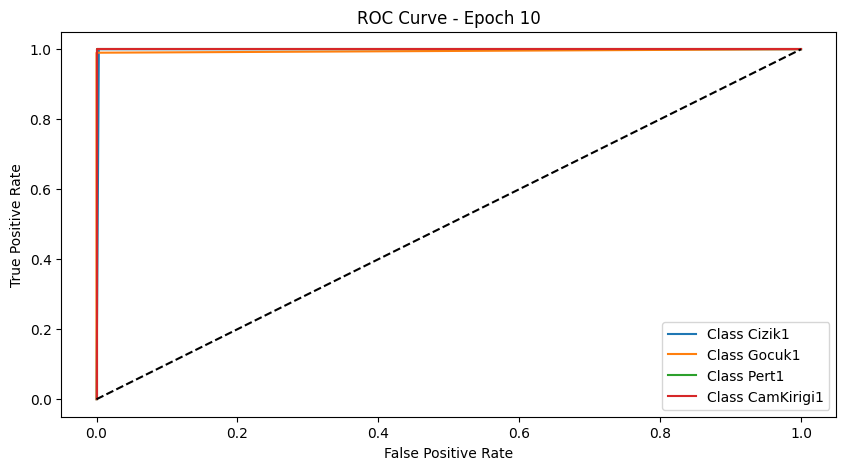

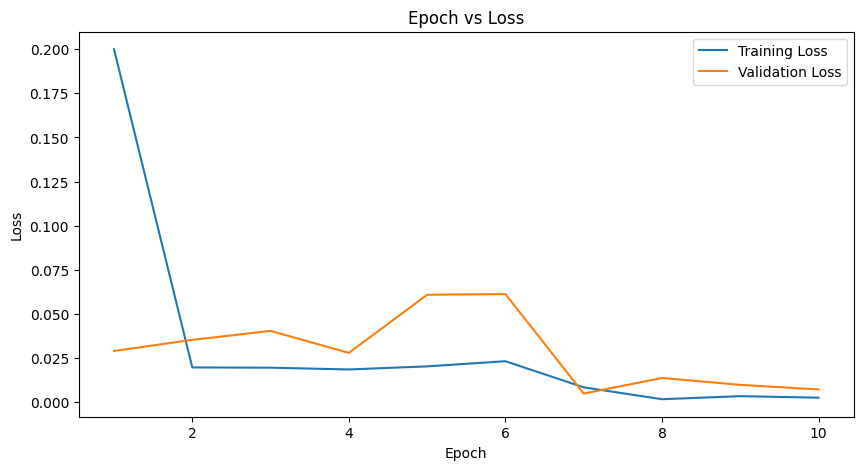

Model başarıyla kaydedildi!


In [ ]:
import os
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from transformers import BeitForImageClassification, BeitFeatureExtractor
from torch import nn, optim
import torch
from PIL import Image
from google.colab import drive
from sklearn.model_selection import train_test_split

# Google Drive'ı bağlama
drive.mount('/content/drive')

# Veri hazırlığı aynı şekilde devam ediyor...
data_dir = "/content/drive/My Drive/YazLabProjesi/DATABASE"
classes = ["Cizik", "Gocuk", "Pert", "CamKirigi"]

image_paths = []
labels = []
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}

for idx, cls in enumerate(classes):
    class_dir = os.path.join(data_dir, cls)
    for img_file in os.listdir(class_dir):
        if any(img_file.lower().endswith(ext) for ext in valid_extensions):
            image_paths.append(os.path.join(class_dir, img_file))
            labels.append(idx)

train_image_paths, val_image_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

class CustomDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = CustomDataset(train_image_paths, train_labels, transform=transform)
val_dataset = CustomDataset(val_image_paths, val_labels, transform=transform)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "gpu")
feature_extractor = BeitFeatureExtractor.from_pretrained("microsoft/beit-base-patch16-224")
model = BeitForImageClassification.from_pretrained(
    "microsoft/beit-base-patch16-224",
    num_labels=len(classes),
    ignore_mismatched_sizes=True
)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

train_losses = []
val_losses = []
train_times = []
val_times = []

num_epochs = 10
for epoch in range(num_epochs):
    # Eğitim
    model.train()
    train_loss = 0
    start_time = time.time()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_time = time.time() - start_time
    train_times.append(train_time)
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Doğrulama
    model.eval()
    val_loss = 0
    val_preds = []
    val_labels_list = []
    start_time = time.time()
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).logits
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_labels_list.extend(labels.cpu().numpy())
    val_time = time.time() - start_time
    val_times.append(val_time)
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Performans Metriği Hesaplamaları
    accuracy = accuracy_score(val_labels_list, val_preds)
    recall = recall_score(val_labels_list, val_preds, average='macro')
    precision = precision_score(val_labels_list, val_preds, average='macro')
    f1 = f1_score(val_labels_list, val_preds, average='macro')
    auc = roc_auc_score(val_labels_list, torch.nn.functional.one_hot(torch.tensor(val_preds), num_classes=len(classes)), multi_class='ovr')
    cm = confusion_matrix(val_labels_list, val_preds)

    # Metrikleri Yazdır
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1-Score: {f1:.4f}, AUC: {auc:.4f}")
    print(f"Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")

    # Karmaşıklık Matrisi ve ROC Eğrisi
    plt.figure(figsize=(10, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix - Epoch {epoch+1}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Eğrisi
    plt.figure(figsize=(10, 5))
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(np.array(val_labels_list) == i, np.array(val_preds) == i)
        plt.plot(fpr, tpr, label=f"Class {classes[i]}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - Epoch {epoch+1}")
    plt.legend()
    plt.show()

# Loss Grafiği
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label="Training Loss")
plt.plot(range(1, num_epochs + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Loss")
plt.legend()
plt.show()

# Modeli Kaydetme
torch.save(model.state_dict(), "/content/drive/My Drive/YazLabProjesi/save/BEIT_final_model.pth")
print("Model başarıyla kaydedildi!")

